# The Autonomous Compliance Sentinel
## Goal 3: XAI and Weakness Tests

| Project | The Autonomous Compliance Sentinel |
| --- | --- |
| Modul | Responsible AI and Data Ethics |
| Authors | Group 2: Singh, Vikrant and Müller, Kay |

### Logistic Regression Explainability Notebook

### What we do here:
- Load the trained Logistic Regression model from Goal 2 artifacts.
- Explain the model using four different XAI methods.
- Compare what each method tells us about the model's decisions.
- Identify weaknesses in the model's learned patterns.

### The four XAI methods we use:

| Method | What it does | Works with |
|---|---|---|
| Linear weights (coef_) | Global explanation: which words push toward Red Flag across ALL proposals | LogReg only, built in |
| SHAP | Global + per-proposal: assigns each word a contribution score using game theory | Any model |
| LIME | Per-proposal: builds a local linear approximation around one specific prediction | Any model |
| Eli5 | Per-proposal: highlights which words in the text drove the decision | LogReg + any model |

### Why interpretability matters for this project:
- EU AI Act Article 12: decisions must be logged in a way that allows post-hoc audit.
- EU AI Act Article 14: human reviewers must be able to understand why a flag was raised.
- Goal 4 (Agent): the agent passes trigger words to the LLM and to humans. LogReg provides these natively via its coefficients.
- A linear model's weights are reproducible and human-readable. The same input always produces the same explanation.


### Imports:

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# XAI libraries
import shap
import eli5
from eli5.formatters import format_as_dict
from lime.lime_text import LimeTextExplainer

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
from sklearn.base import BaseEstimator, ClassifierMixin

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
print("All imports OK")

All imports OK


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load data:

We load the same dataset as Goal 2 and use the same split parameters so results are directly comparable.


In [2]:
df = pd.read_csv("proposals_1000_EN.csv")

# y = 1 means Red Flag, y = 0 means Compliant
df["y"] = (df["label"] == "Red Flag").astype(int)

print(f"Total proposals: {len(df)}")
print(f"Red Flag: {df['y'].sum()}  |  Compliant: {(df['y']==0).sum()}")
print(f"Red Flag rate: {df['y'].mean():.1%}")

Total proposals: 1000
Red Flag: 333  |  Compliant: 667
Red Flag rate: 33.3%


### Train/test split:

Same settings as Goal 2: 80/20, stratified, random_state=42.
This ensures the model we evaluate here is directly comparable to the one in the friend's sentinel package.


In [3]:
idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, stratify=df["y"], random_state=42
)

#The following lines mean that from the dataset take only the rows whose index is in idx_train, idx_test (WE ARE USING .loc for it)
# and return the description column and if the column has a NaN value, fill it woth an emty string.
X_train = df.loc[idx_train, "description"].fillna("") 
X_test  = df.loc[idx_test,  "description"].fillna("")
# We are doing the aforementioned for test dataset as well but without filling in the NaN values.
# WHy not fill the NAN values in target variable? Because we are using stratified sampling and if 
# we fill the NaN values in the target variable, we will have a different distribution of 
# the target variable in the train and test sets. This will lead to a biased model.
y_train = df.loc[idx_train, "y"]
y_test  = df.loc[idx_test,  "y"]

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Train Red Flag rate: {y_train.mean():.1%}")
print(f"Test  Red Flag rate: {y_test.mean():.1%}")

Train: 800  |  Test: 200
Train Red Flag rate: 33.2%
Test  Red Flag rate: 33.5%


In [4]:
class ThresholdAdjustor(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.4): 
        #estimator here is the model we pass in. COULD BE ANY.
        # threshold is pretty self explanatory
        self.estimator=estimator # Why do we do self. something? 
        #Because we want to use it in other methods of the class. 
        # If we don't do self. then it will be a local variable 
        # and will not be accessible in other methods of the class.
        self.threshold=threshold
    def fit(self, X, y):
        self.estimator.fit(X, y)
        self.classes_= self.estimator.classes_ # What is .classes_? It is an attribute of the estimator that stores the classes of the target variable.
        return self
    def predict_proba(self, X):
        # predict_proba is a method of the estimator that returns the probability of each class for each sample.
        # We need this because we want to adjust the threshold for classification.
        # It will help with imbalanced datasets. For example, if we have a dataset with 90% of class 0 and 10% of class 1,
        # the model will be biased towards class 0. If we set the threshold to 0.4, then the model will classify a sample as class 1 if the probability of class 1 is greater than 0.4.
        return self.estimator.predict_proba(X)
    def predict(self, X):
        proba=self.estimator.predict_proba(X)[:,1] # We are only interested in the probability of class 1 (Red Flag)
        return (proba>=self.threshold).astype(int)
    @property
    def coef_(self):
        return self.estimator.coef_
    
    @property
    def intercept_(self):
        return self.estimator.intercept_


    


---

## Section 1: Baseline Model

We establish a baseline using the exact same settings as the Goal 2 sentinel package.
This is our fixed reference point. Every experiment below is judged against these numbers.

### Settings:
- `stop_words="english"`: sklearn's built-in stop list removes common filler words.
- `ngram_range=(1, 2)`: single words and two-word phrases.
- `threshold=0.4`: predict Red Flag if the model probability is 0.4 or above.

### The known limitation:
sklearn's stop list also removes "not", "without", "cannot" alongside genuine filler.
"data stored without consent" loses "without" and becomes "data stored consent".
The violation signal is weakened. Sections 2 and 3 address this.

In [5]:
pipeline_baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),    # single words and two-word phrases
        min_df=2,              # ignore terms in fewer than 2 documents
        max_df=0.9,            # ignore terms in more than 90% of documents
        stop_words="english",  # sklearn built-in stop list (also removes negation words)
        sublinear_tf=True,     # log(tf) instead of raw tf
    )),
    ("clf", ThresholdAdjustor(
        estimator=LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
        threshold=0.4,
    )),
])

pipeline_baseline.fit(X_train, y_train)
y_pred_baseline  = pipeline_baseline.predict(X_test)
y_proba_baseline = pipeline_baseline.predict_proba(X_test)[:, 1]

prec_base = round(precision_score(y_test, y_pred_baseline), 3)
rec_base  = round(recall_score(y_test, y_pred_baseline), 3)
f1_base   = round(f1_score(y_test, y_pred_baseline), 3)
auc_base  = round(roc_auc_score(y_test, y_proba_baseline), 3)

print("Baseline: stop_words=english, ngram (1,2), threshold 0.4")
print(f"Precision : {prec_base}")
print(f"Recall    : {rec_base}")
print(f"F1        : {f1_base}")
print(f"ROC-AUC   : {auc_base}")

Baseline: stop_words=english, ngram (1,2), threshold 0.4
Precision : 0.855
Recall    : 0.97
F1        : 0.909
ROC-AUC   : 0.991


### Confusion matrix: Baseline

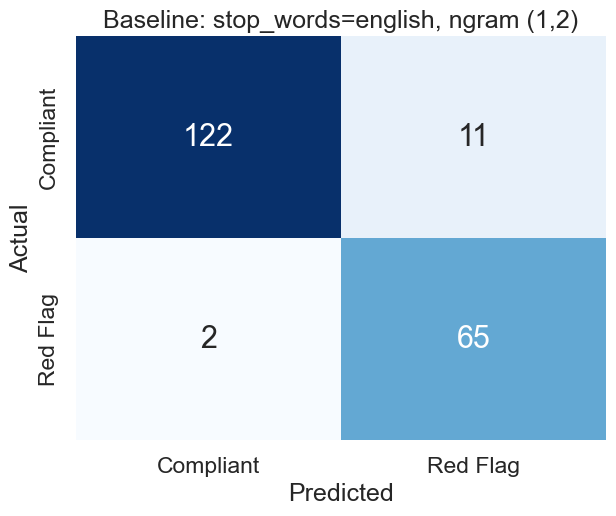

False negatives (missed violations): 2  <-- most costly
False positives (over-flagging)    : 11
Miss rate: 3.0%


In [6]:
cm_arr = confusion_matrix(y_test, y_pred_baseline)
tn, fp, fn, tp = cm_arr.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Baseline: stop_words=english, ngram (1,2)")
plt.tight_layout(); plt.show()

print(f"False negatives (missed violations): {fn}  <-- most costly")
print(f"False positives (over-flagging)    : {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

### Top terms: Baseline

The chart below shows which terms the model learned to associate with Red Flag (red bars)
and Compliant (blue bars) in this configuration.

These are the exact LogReg coefficients. A positive value means that term pushes
the prediction toward Red Flag. A negative value pushes toward Compliant.
The larger the bar, the stronger the push.

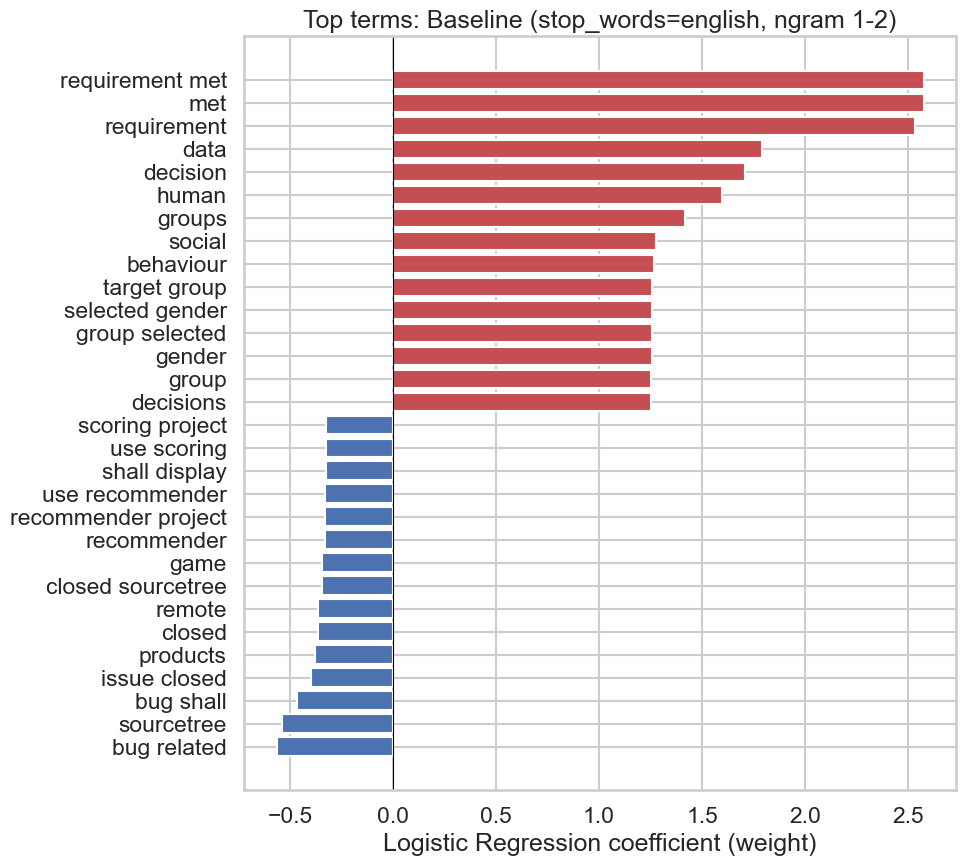

Top 10 Red Flag indicators:
met                2.577
requirement met    2.577
requirement        2.534
data               1.792
decision           1.707
human              1.599
groups             1.420
social             1.275
behaviour          1.266
gender             1.260

Top 10 Compliant indicators:
bug related         -0.565
sourcetree          -0.541
bug shall           -0.467
issue closed        -0.396
products            -0.377
closed              -0.363
remote              -0.362
closed sourcetree   -0.346
game                -0.344
recommender         -0.332


In [7]:
# Extract vec and clf from this specific experiment pipeline.
# vec: the TfidfVectorizer fitted on the training data for this experiment.
# clf: the ThresholdAdjustor wrapping LogisticRegression for this experiment.
vec_exp = pipeline_baseline.named_steps["tfidf"]
clf_exp = pipeline_baseline.named_steps["clf"]

# clf_exp.coef_[0] gives us the weight (coefficient) for every term in the vocabulary.
# A positive weight pushes the prediction toward Red Flag.
# A negative weight pushes the prediction toward Compliant.
# The [0] removes the outer wrapper: coef_ shape is (1, n_features) for binary classification.
coefs = pd.Series(clf_exp.coef_[0], index=vec_exp.get_feature_names_out())

n = 15
top_pos = coefs.nlargest(n)   # strongest push toward Red Flag
top_neg = coefs.nsmallest(n)  # strongest push toward Compliant
top_all = pd.concat([top_neg, top_pos]).sort_values()

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_all.values]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_all.index, top_all.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top terms: Baseline (stop_words=english, ngram 1-2)")
ax.set_xlabel("Logistic Regression coefficient (weight)")
plt.tight_layout(); plt.show()

print("Top 10 Red Flag indicators:")
print(top_pos.head(10).round(3).to_string())
print()
print("Top 10 Compliant indicators:")
print(top_neg.head(10).round(3).to_string())

---

## Section 2: First Attempt at Fixing the Stop Word Problem

### The idea:
Instead of using `stop_words="english"` (which removes negation words), we remove
the stop word list entirely and use very large ngrams: `ngram_range=(5, 6)`.

The reasoning was: if each vocabulary term is a 5 or 6 word phrase, negation words
like "not" will naturally be captured inside those longer phrases. For example,
instead of learning the word "not" separately, the model might learn the phrase
"this requirement is not met".

### Why we ran this experiment:
This was a direct response to the limitation identified in Section 1. We wanted to
see whether large ngrams alone could preserve the negation signal without needing
a custom tokenizer.

### What we found:
This approach made the model significantly worse. The confusion matrix and top terms
chart below tell the full story.

In [8]:
# Experiment: no stop_words, no custom tokenizer, large ngrams (5,6).
exp_56 = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(5, 6),    # 5 and 6 word raw phrases, no stop word filtering
        min_df=2,              # ignore terms in fewer than 2 documents
        max_df=0.9,            # ignore terms in more than 90% of documents
        sublinear_tf=True,     # log(tf) instead of raw tf
    )),
    ("clf", ThresholdAdjustor(
        estimator=LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
        threshold=0.4,
    )),
])

exp_56.fit(X_train, y_train)
y_pred_56  = exp_56.predict(X_test)
y_proba_56 = exp_56.predict_proba(X_test)[:, 1]

prec_56 = round(precision_score(y_test, y_pred_56), 3)
rec_56  = round(recall_score(y_test, y_pred_56), 3)
f1_56   = round(f1_score(y_test, y_pred_56), 3)
auc_56  = round(roc_auc_score(y_test, y_proba_56), 3)

print("Experiment: no stop_words, ngram (5,6), threshold 0.4")
print(f"Precision : {prec_56}")
print(f"Recall    : {rec_56}")
print(f"F1        : {f1_56}")
print(f"ROC-AUC   : {auc_56}")

Experiment: no stop_words, ngram (5,6), threshold 0.4
Precision : 0.667
Recall    : 0.985
F1        : 0.795
ROC-AUC   : 0.966


### Confusion matrix: no stop_words, ngram (5,6)

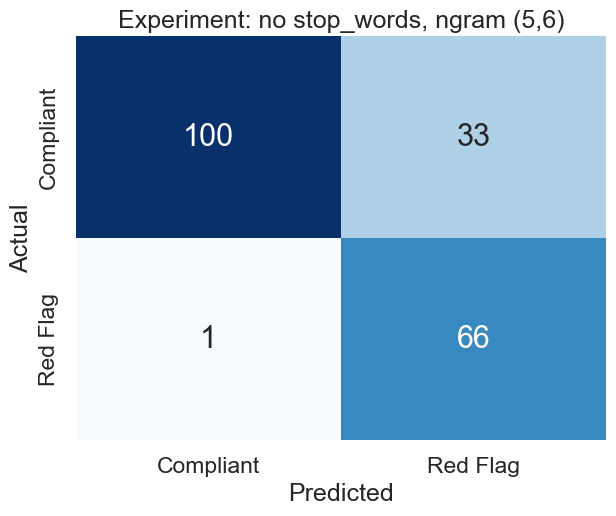

False negatives (missed violations): 1  <-- most costly
False positives (over-flagging)    : 33
Miss rate: 1.5%


In [9]:
cm_arr = confusion_matrix(y_test, y_pred_56)
tn, fp, fn, tp = cm_arr.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Experiment: no stop_words, ngram (5,6)")
plt.tight_layout(); plt.show()

print(f"False negatives (missed violations): {fn}  <-- most costly")
print(f"False positives (over-flagging)    : {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

### Top terms: no stop_words, ngram (5,6)

Pay close attention to the red bars here. They will be full 5 or 6 word phrases.
Notice how they are all very specific, overlapping fragments of the same synthetic
sentences. This is exactly the vocabulary sparsity problem:
the model memorised a handful of specific phrasings instead of learning a general signal.

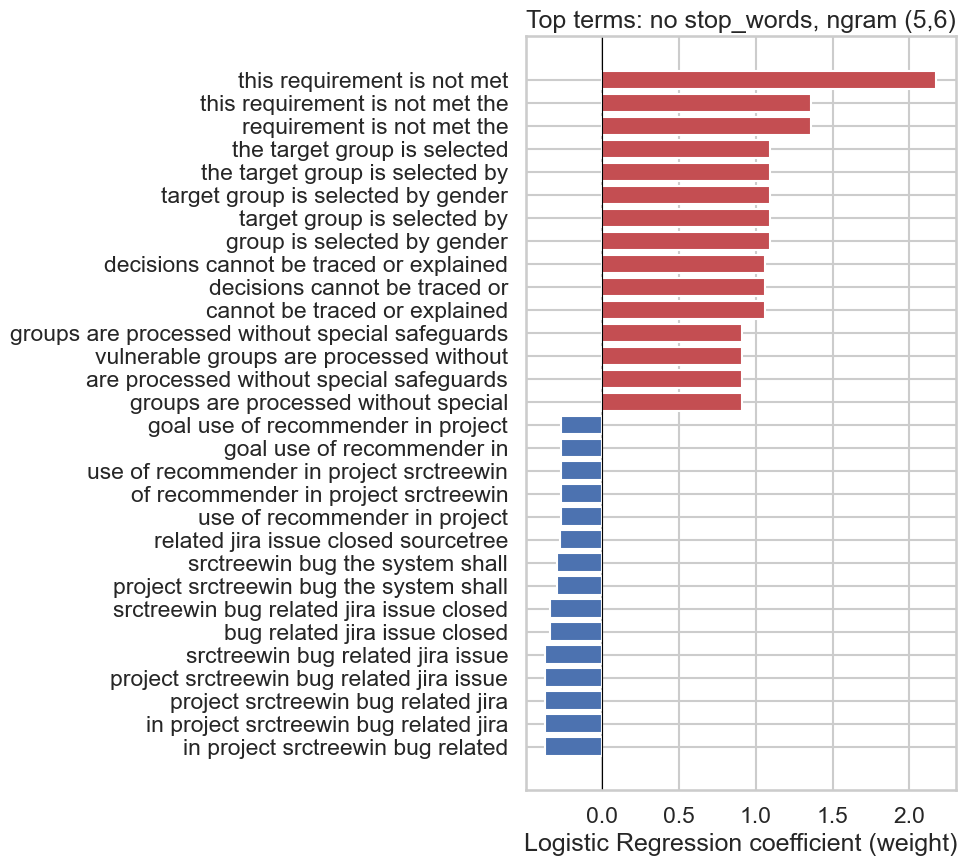

Top 10 Red Flag indicators:
this requirement is not met           2.176
requirement is not met the            1.362
this requirement is not met the       1.362
group is selected by gender           1.090
target group is selected by           1.090
target group is selected by gender    1.090
the target group is selected          1.090
the target group is selected by       1.090
cannot be traced or explained         1.061
decisions cannot be traced or         1.061

Top 10 Compliant indicators:
in project srctreewin bug related           -0.373
in project srctreewin bug related jira      -0.373
project srctreewin bug related jira         -0.373
project srctreewin bug related jira issue   -0.373
srctreewin bug related jira issue           -0.373
bug related jira issue closed               -0.344
srctreewin bug related jira issue closed    -0.344
project srctreewin bug the system shall     -0.299
srctreewin bug the system shall             -0.299
related jira issue closed sourcetree       

In [10]:
# Extract vec and clf from this specific experiment pipeline.
# vec: the TfidfVectorizer fitted on the training data for this experiment.
# clf: the ThresholdAdjustor wrapping LogisticRegression for this experiment.
vec_exp = exp_56.named_steps["tfidf"]
clf_exp = exp_56.named_steps["clf"]

# clf_exp.coef_[0] gives us the weight (coefficient) for every term in the vocabulary.
# A positive weight pushes the prediction toward Red Flag.
# A negative weight pushes the prediction toward Compliant.
# The [0] removes the outer wrapper: coef_ shape is (1, n_features) for binary classification.
coefs = pd.Series(clf_exp.coef_[0], index=vec_exp.get_feature_names_out())

n = 15
top_pos = coefs.nlargest(n)   # strongest push toward Red Flag
top_neg = coefs.nsmallest(n)  # strongest push toward Compliant
top_all = pd.concat([top_neg, top_pos]).sort_values()

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_all.values]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_all.index, top_all.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top terms: no stop_words, ngram (5,6)")
ax.set_xlabel("Logistic Regression coefficient (weight)")
plt.tight_layout(); plt.show()

print("Top 10 Red Flag indicators:")
print(top_pos.head(10).round(3).to_string())
print()
print("Top 10 Compliant indicators:")
print(top_neg.head(10).round(3).to_string())

### Why the (5,6) approach failed:

**Root cause: vocabulary sparsity.**

`ngram_range=(5, 6)` extracts only sequences of 5 or 6 consecutive raw words.
At that length, very few proposals share the exact same phrase twice. The vocabulary
becomes so sparse that most proposals produce a TF-IDF vector that is almost entirely zeros.

When a proposal has mostly zero features, LogReg has almost no signal to work with.
It falls back to outputting a probability close to 0.5. With `threshold=0.4`,
anything above 0.4 gets flagged. So nearly everything gets flagged.

**What the top terms confirmed:**

The highest-weighted Red Flag phrases are overlapping windows of the same single sentence
in the training data. The model was not learning a generalizable policy signal.
It was memorising one specific phrasing from the synthetic data.

A real proposal saying "this spec does not comply with Regulation E" instead of the
exact phrase "this requirement is not met" would get zero signal from these features.

**Conclusion:** Large ngrams alone do not fix the stop word problem.
We need a smarter approach that strips filler words while preserving negation.
That is what the POS tokenizer in Section 3 does.

---

## Section 3: POS Tokenizer + Ngram Experiments

### The fix: Part-of-Speech tagging:

Instead of removing words by identity (a hardcoded list) or using raw large ngrams,
we remove words by their **grammatical role** using spaCy's POS tagger.

spaCy reads each sentence and assigns every word a POS tag:

| POS Tag | What it means | Examples | Decision |
|---|---|---|---|
| NOUN | a thing or concept | data, consent, system | **Keep** |
| VERB | an action | store, process, violate | **Keep** |
| ADV | modifies a verb | not, never, automatically | **Keep** |
| ADJ | describes a noun | prohibited, vulnerable | **Keep** |
| ADP | preposition | without, against, under | **Keep** |
| DET | article or determiner | the, a, an, this, that | Remove |
| CCONJ | coordinating conjunction | and, but, or | Remove |
| PUNCT | punctuation | . , ; : | Remove |
| SPACE | whitespace | (blank) | Remove |

`REMOVE_POS` is a set of the tags we want to strip.
Nothing is hardcoded by word identity. If the language of the proposals changes,
the grammar does not.

### Why this solves both problems at once:
- Negation words ("not", "without", "cannot") are grammatically ADV or ADP. They are **kept**.
- Filler words ("the", "a", "and") are grammatically DET or CCONJ. They are **removed**.
- Because filler is stripped before n-gramming, a 3-content-word phrase spans roughly
  5 to 7 words of original text. We get richer phrases with smaller ngram numbers.

### Three ngram experiments:

| Experiment | ngram_range | What it captures |
|---|---|---|
| Experiment B | (1, 2) | single content words and content word pairs |
| Experiment C | (2, 3) | content word pairs and content word triplets |
| Experiment D | (3, 3) | only content word triplets, phrase-level signals |

In [11]:
import spacy
nlp=spacy.load("en_core_web_sm")
remove_pos={"DET","CCONJ","PUNCT","SPACE"}

def tokenizer(text):
    doc=nlp(text.lower())
    tokens=[]
    for i in doc:
        if i.pos_ not in remove_pos and not i.is_space and len(i.text)>1:
            # What we are doing in the if statement is that we are 
            # checking if the part of speech of the token is not in the 
            # remove_pos set, if the token is not a space, 
            # and if the length of the token is greater than 1. 
            # If all these conditions are met, we append the token to the tokens list.
            # So basically we are removing all the tokens that are not useful for our analysis.
            # All in all what we are doing is that we are tokenizing the text and removing all the tokens that are not useful for our analysis.
            # For example, 
            # we are removing all the determiners (the, a, an), 
            # conjunctions (and, or, but), punctuation marks, and spaces. 
            # We are also removing all the tokens that are only one character long because they are not useful for our analysis.
            tokens.append(i.text)
    return tokens


### Experiment B: POS tokenizer + ngram (1,2)

`ngram_range=(1, 2)` on POS-filtered tokens means the vocabulary contains:
- Single content words: "not", "consent", "prohibited", "human"
- Two-word content phrases: "not met", "without consent", "no human"

This is the most general POS setting. The vocabulary is rich and covers many ways
of phrasing a violation. Compare the top terms chart here against the baseline:
you should see "not" and "without" reappear as meaningful Red Flag indicators.

In [12]:
exp_12 = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenizer,  # POS tokenizer: grammar decides, not a hardcoded word list
        ngram_range=(1, 2),   # single content words and content word pairs
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
    )),
    ("clf", ThresholdAdjustor(
        estimator=LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
        threshold=0.4,
    )),
])

exp_12.fit(X_train, y_train)
y_pred_12  = exp_12.predict(X_test)
y_proba_12 = exp_12.predict_proba(X_test)[:, 1]

prec_12 = round(precision_score(y_test, y_pred_12), 3)
rec_12  = round(recall_score(y_test, y_pred_12), 3)
f1_12   = round(f1_score(y_test, y_pred_12), 3)
auc_12  = round(roc_auc_score(y_test, y_proba_12), 3)

print("Experiment B: POS tokenizer + ngram (1,2)")
print(f"Precision : {prec_12}")
print(f"Recall    : {rec_12}")
print(f"F1        : {f1_12}")
print(f"ROC-AUC   : {auc_12}")

Experiment B: POS tokenizer + ngram (1,2)
Precision : 0.882
Recall    : 1.0
F1        : 0.937
ROC-AUC   : 0.996


### Confusion matrix: Experiment B

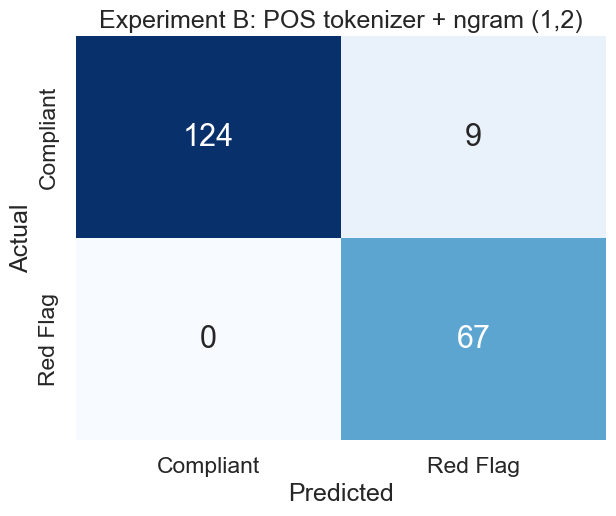

False negatives (missed violations): 0  <-- most costly
False positives (over-flagging)    : 9
Miss rate: 0.0%


In [13]:
cm_arr = confusion_matrix(y_test, y_pred_12)
tn, fp, fn, tp = cm_arr.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Experiment B: POS tokenizer + ngram (1,2)")
plt.tight_layout(); plt.show()

print(f"False negatives (missed violations): {fn}  <-- most costly")
print(f"False positives (over-flagging)    : {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

### Top terms: Experiment B

With the POS tokenizer active, check whether negation words like "not" and "without"
now appear in the Red Flag indicators. Compare this directly against the Baseline chart.
In the baseline these words were stripped. Here they should survive.

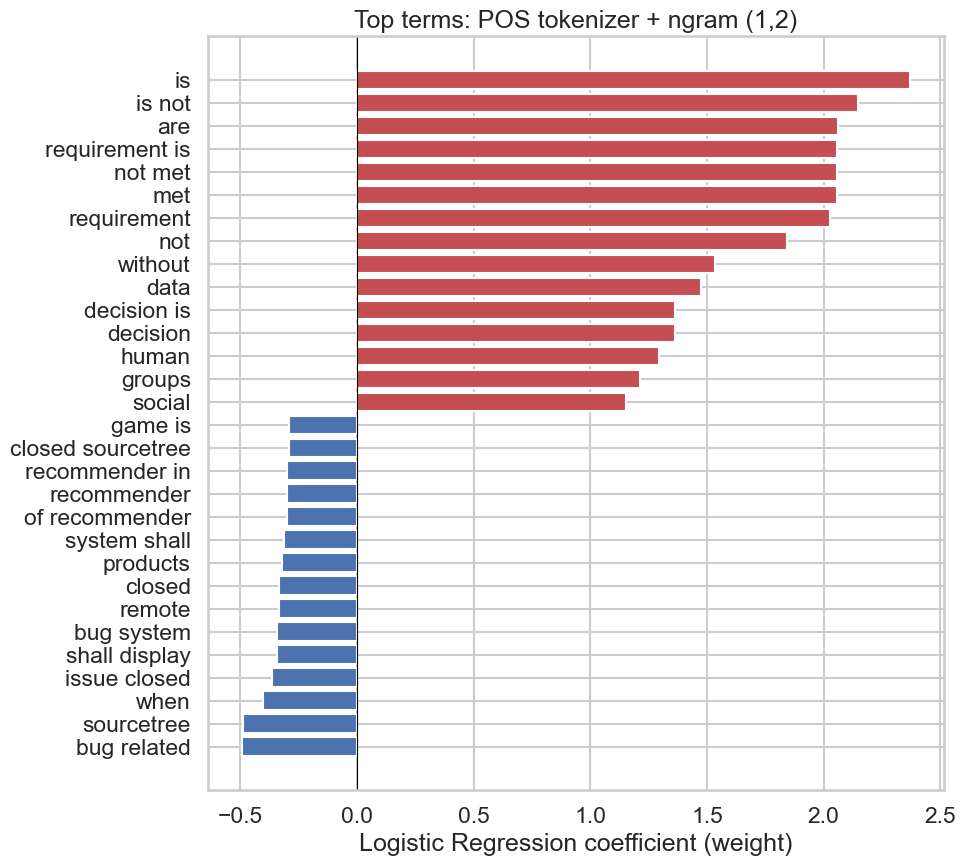

Top 10 Red Flag indicators:
is                2.371
is not            2.149
are               2.060
met               2.056
not met           2.056
requirement is    2.056
requirement       2.028
not               1.843
without           1.536
data              1.476

Top 10 Compliant indicators:
bug related     -0.493
sourcetree      -0.487
when            -0.404
issue closed    -0.362
shall display   -0.343
bug system      -0.341
remote          -0.334
closed          -0.332
products        -0.321
system shall    -0.310


In [14]:
# Extract vec and clf from this specific experiment pipeline.
# vec: the TfidfVectorizer fitted on the training data for this experiment.
# clf: the ThresholdAdjustor wrapping LogisticRegression for this experiment.
vec_exp = exp_12.named_steps["tfidf"]
clf_exp = exp_12.named_steps["clf"]

# clf_exp.coef_[0] gives us the weight (coefficient) for every term in the vocabulary.
# A positive weight pushes the prediction toward Red Flag.
# A negative weight pushes the prediction toward Compliant.
# The [0] removes the outer wrapper: coef_ shape is (1, n_features) for binary classification.
coefs = pd.Series(clf_exp.coef_[0], index=vec_exp.get_feature_names_out())

n = 15
top_pos = coefs.nlargest(n)   # strongest push toward Red Flag
top_neg = coefs.nsmallest(n)  # strongest push toward Compliant
top_all = pd.concat([top_neg, top_pos]).sort_values()

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_all.values]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_all.index, top_all.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top terms: POS tokenizer + ngram (1,2)")
ax.set_xlabel("Logistic Regression coefficient (weight)")
plt.tight_layout(); plt.show()

print("Top 10 Red Flag indicators:")
print(top_pos.head(10).round(3).to_string())
print()
print("Top 10 Compliant indicators:")
print(top_neg.head(10).round(3).to_string())

### Experiment C: POS tokenizer + ngram (2,3)

`ngram_range=(2, 3)` on POS-filtered tokens means the vocabulary contains:
- Two-word content phrases: "not met", "without consent", "no human"
- Three-word content phrases: "not met compliance", "stored without consent"

Single words are no longer in the vocabulary. The model only learns multi-word
patterns. The top terms chart should now show only phrases, never single words.

In [15]:
exp_23 = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenizer,  # POS tokenizer: grammar decides, not a hardcoded word list
        ngram_range=(2, 3),   # content word pairs and content word triplets
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
    )),
    ("clf", ThresholdAdjustor(
        estimator=LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
        threshold=0.4,
    )),
])

exp_23.fit(X_train, y_train)
y_pred_23  = exp_23.predict(X_test)
y_proba_23 = exp_23.predict_proba(X_test)[:, 1]

prec_23 = round(precision_score(y_test, y_pred_23), 3)
rec_23  = round(recall_score(y_test, y_pred_23), 3)
f1_23   = round(f1_score(y_test, y_pred_23), 3)
auc_23  = round(roc_auc_score(y_test, y_proba_23), 3)

print("Experiment C: POS tokenizer + ngram (2,3)")
print(f"Precision : {prec_23}")
print(f"Recall    : {rec_23}")
print(f"F1        : {f1_23}")
print(f"ROC-AUC   : {auc_23}")

Experiment C: POS tokenizer + ngram (2,3)
Precision : 0.793
Recall    : 0.97
F1        : 0.872
ROC-AUC   : 0.99


### Confusion matrix: Experiment C

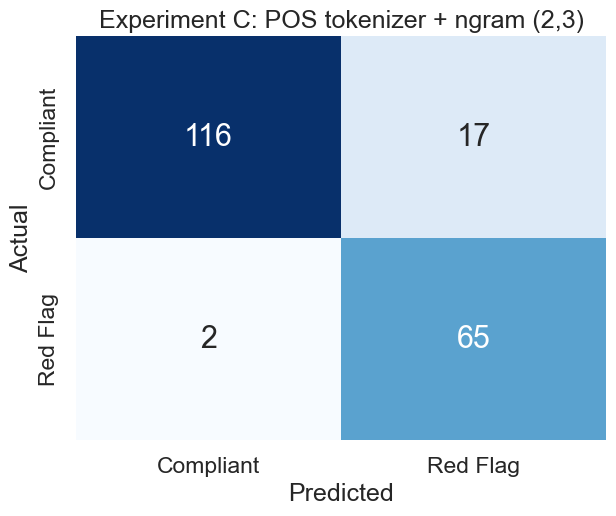

False negatives (missed violations): 2  <-- most costly
False positives (over-flagging)    : 17
Miss rate: 3.0%


In [16]:
cm_arr = confusion_matrix(y_test, y_pred_23)
tn, fp, fn, tp = cm_arr.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Experiment C: POS tokenizer + ngram (2,3)")
plt.tight_layout(); plt.show()

print(f"False negatives (missed violations): {fn}  <-- most costly")
print(f"False positives (over-flagging)    : {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

### Top terms: Experiment C

All terms here are at least two content words long. Check whether the phrases are
more interpretable than the single words in Experiment B. Phrases like "not met",
"without consent", "is selected" are immediately readable as policy signals.

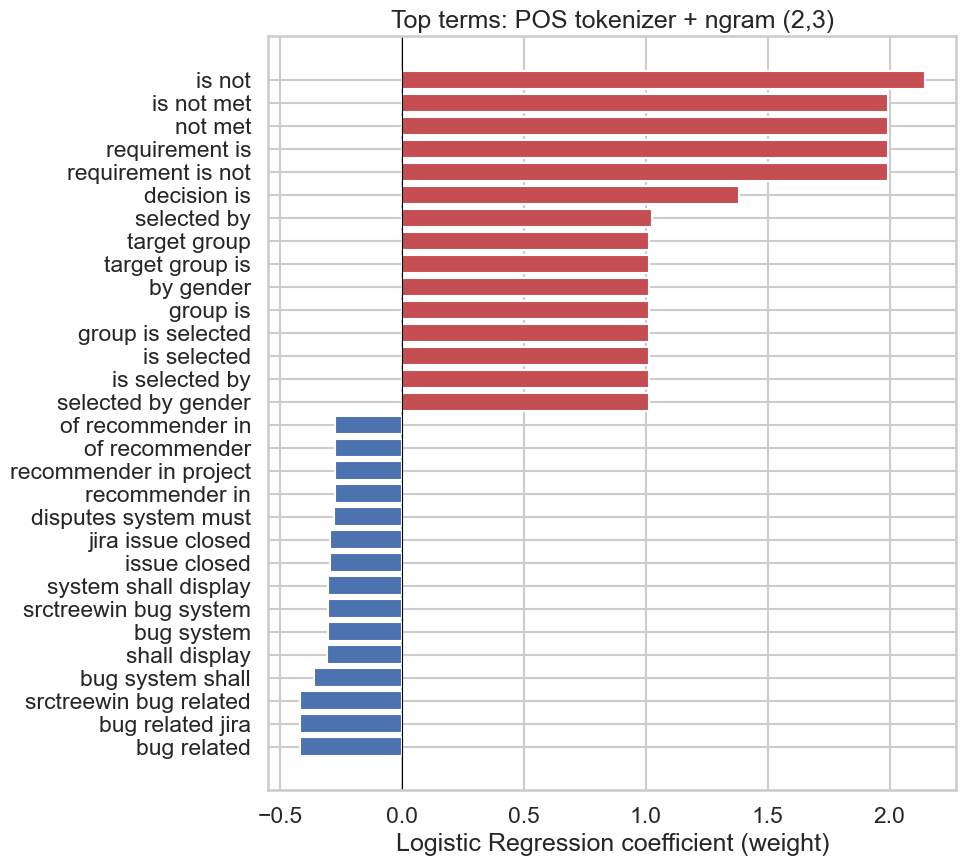

Top 10 Red Flag indicators:
is not                2.144
is not met            1.992
not met               1.992
requirement is        1.992
requirement is not    1.992
decision is           1.380
selected by           1.024
by gender             1.012
group is              1.012
group is selected     1.012

Top 10 Compliant indicators:
bug related              -0.421
bug related jira         -0.421
srctreewin bug related   -0.421
bug system shall         -0.361
shall display            -0.310
bug system               -0.306
srctreewin bug system    -0.306
system shall display     -0.303
issue closed             -0.297
jira issue closed        -0.297


In [17]:
# Extract vec and clf from this specific experiment pipeline.
# vec: the TfidfVectorizer fitted on the training data for this experiment.
# clf: the ThresholdAdjustor wrapping LogisticRegression for this experiment.
vec_exp = exp_23.named_steps["tfidf"]
clf_exp = exp_23.named_steps["clf"]

# clf_exp.coef_[0] gives us the weight (coefficient) for every term in the vocabulary.
# A positive weight pushes the prediction toward Red Flag.
# A negative weight pushes the prediction toward Compliant.
# The [0] removes the outer wrapper: coef_ shape is (1, n_features) for binary classification.
coefs = pd.Series(clf_exp.coef_[0], index=vec_exp.get_feature_names_out())

n = 15
top_pos = coefs.nlargest(n)   # strongest push toward Red Flag
top_neg = coefs.nsmallest(n)  # strongest push toward Compliant
top_all = pd.concat([top_neg, top_pos]).sort_values()

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_all.values]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_all.index, top_all.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top terms: POS tokenizer + ngram (2,3)")
ax.set_xlabel("Logistic Regression coefficient (weight)")
plt.tight_layout(); plt.show()

print("Top 10 Red Flag indicators:")
print(top_pos.head(10).round(3).to_string())
print()
print("Top 10 Compliant indicators:")
print(top_neg.head(10).round(3).to_string())

### Experiment D: POS tokenizer + ngram (3,3)

`ngram_range=(3, 3)` on POS-filtered tokens means the vocabulary contains ONLY
three-content-word phrases. No single words. No two-word pairs.

Because the POS tokenizer has already removed filler words, a 3-content-word
phrase spans roughly 5 to 7 words of the original sentence. For example:
- Content triplet "requirement is not" spans "this requirement is not met"
- Content triplet "groups processed safeguards" spans "vulnerable groups are processed without special safeguards"

This produces the most human-readable trigger phrases. When passed to the Goal 4
LLM agent as grounding context, these phrases are immediately interpretable as
policy violation signals rather than single ambiguous words.

In [18]:
exp_33 = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenizer,  # POS tokenizer: grammar decides, not a hardcoded word list
        ngram_range=(3, 3),   # only content word triplets, phrase-level signals
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
    )),
    ("clf", ThresholdAdjustor(
        estimator=LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
        threshold=0.4,
    )),
])

exp_33.fit(X_train, y_train)
y_pred_33  = exp_33.predict(X_test)
y_proba_33 = exp_33.predict_proba(X_test)[:, 1]

prec_33 = round(precision_score(y_test, y_pred_33), 3)
rec_33  = round(recall_score(y_test, y_pred_33), 3)
f1_33   = round(f1_score(y_test, y_pred_33), 3)
auc_33  = round(roc_auc_score(y_test, y_proba_33), 3)

print("Experiment D: POS tokenizer + ngram (3,3)")
print(f"Precision : {prec_33}")
print(f"Recall    : {rec_33}")
print(f"F1        : {f1_33}")
print(f"ROC-AUC   : {auc_33}")

Experiment D: POS tokenizer + ngram (3,3)
Precision : 0.78
Recall    : 0.955
F1        : 0.859
ROC-AUC   : 0.987


### Confusion matrix: Experiment D

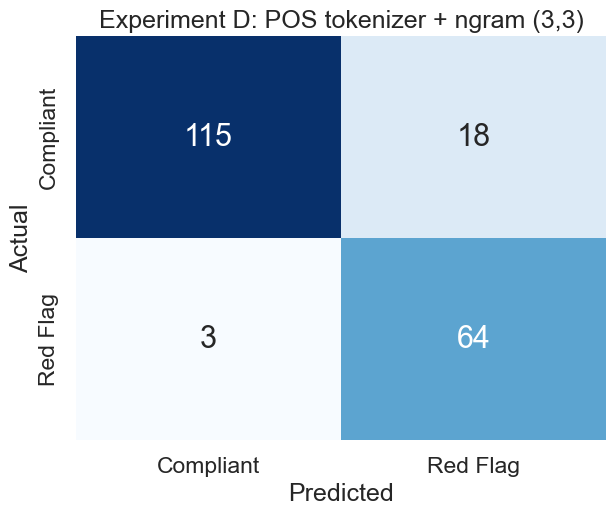

False negatives (missed violations): 3  <-- most costly
False positives (over-flagging)    : 18
Miss rate: 4.5%


In [19]:
cm_arr = confusion_matrix(y_test, y_pred_33)
tn, fp, fn, tp = cm_arr.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Experiment D: POS tokenizer + ngram (3,3)")
plt.tight_layout(); plt.show()

print(f"False negatives (missed violations): {fn}  <-- most costly")
print(f"False positives (over-flagging)    : {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

### Top terms: Experiment D

Every term here is a three-content-word phrase. These are the trigger phrases that
will be passed to the Goal 4 LLM agent. Ask yourself: could a human reviewer or an
LLM immediately understand why a proposal containing "requirement is not" or
"groups processed safeguards" might be a policy violation? If yes, the XAI is working.

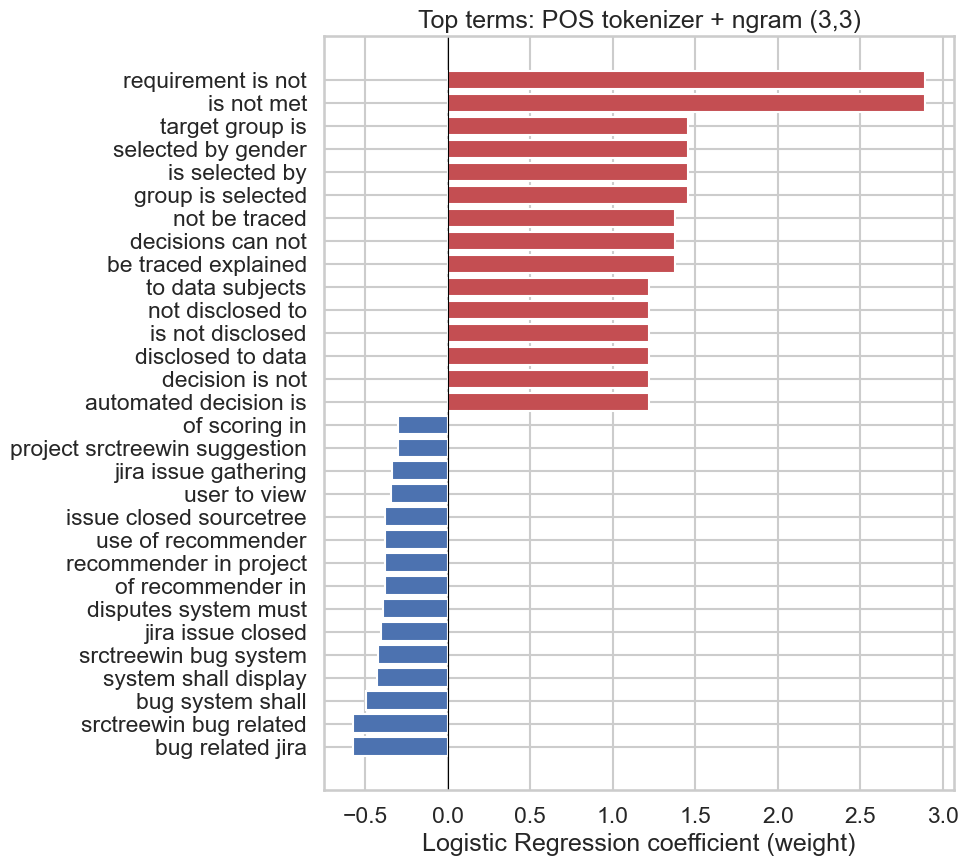

Top 10 Red Flag indicators:
is not met               2.894
requirement is not       2.894
group is selected        1.456
is selected by           1.456
selected by gender       1.456
target group is          1.456
be traced explained      1.376
decisions can not        1.376
not be traced            1.376
automated decision is    1.217

Top 10 Compliant indicators:
bug related jira         -0.576
srctreewin bug related   -0.576
bug system shall         -0.497
system shall display     -0.429
srctreewin bug system    -0.423
jira issue closed        -0.407
disputes system must     -0.393
of recommender in        -0.382
recommender in project   -0.382
use of recommender       -0.382


In [20]:
# Extract vec and clf from this specific experiment pipeline.
# vec: the TfidfVectorizer fitted on the training data for this experiment.
# clf: the ThresholdAdjustor wrapping LogisticRegression for this experiment.
vec_exp = exp_33.named_steps["tfidf"]
clf_exp = exp_33.named_steps["clf"]

# clf_exp.coef_[0] gives us the weight (coefficient) for every term in the vocabulary.
# A positive weight pushes the prediction toward Red Flag.
# A negative weight pushes the prediction toward Compliant.
# The [0] removes the outer wrapper: coef_ shape is (1, n_features) for binary classification.
coefs = pd.Series(clf_exp.coef_[0], index=vec_exp.get_feature_names_out())

n = 15
top_pos = coefs.nlargest(n)   # strongest push toward Red Flag
top_neg = coefs.nsmallest(n)  # strongest push toward Compliant
top_all = pd.concat([top_neg, top_pos]).sort_values()

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_all.values]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_all.index, top_all.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top terms: POS tokenizer + ngram (3,3)")
ax.set_xlabel("Logistic Regression coefficient (weight)")
plt.tight_layout(); plt.show()

print("Top 10 Red Flag indicators:")
print(top_pos.head(10).round(3).to_string())
print()
print("Top 10 Compliant indicators:")
print(top_neg.head(10).round(3).to_string())

---

## Summary: Comparing all experiments

The chart below compares Precision, Recall, and F1 across all five configurations.

### How to read this chart:
- **Precision**: of all proposals the model flagged, how many were real violations?
  Low precision means reviewers receive many false alarms.
- **Recall**: of all real violations, how many did the model catch?
  Low recall means violations slip through undetected.
- **F1**: harmonic mean of Precision and Recall. Balances both in a single number.

### Priority (Goal 1, slide 14):
A missed violation is more costly than a false alarm.
Recall is our primary metric. We accept lower precision if recall stays high.
The Human-in-the-Loop gate filters false positives before any write-back occurs.

Full results table:
                             Precision  Recall     F1  ROC-AUC
Baseline\n(stop_words, 1-2)      0.855   0.970  0.909    0.991
Raw ngram\n(5,6)                 0.667   0.985  0.795    0.966
POS\nngram (1,2)                 0.882   1.000  0.937    0.996
POS\nngram (2,3)                 0.793   0.970  0.872    0.990
POS\nngram (3,3)                 0.780   0.955  0.859    0.987



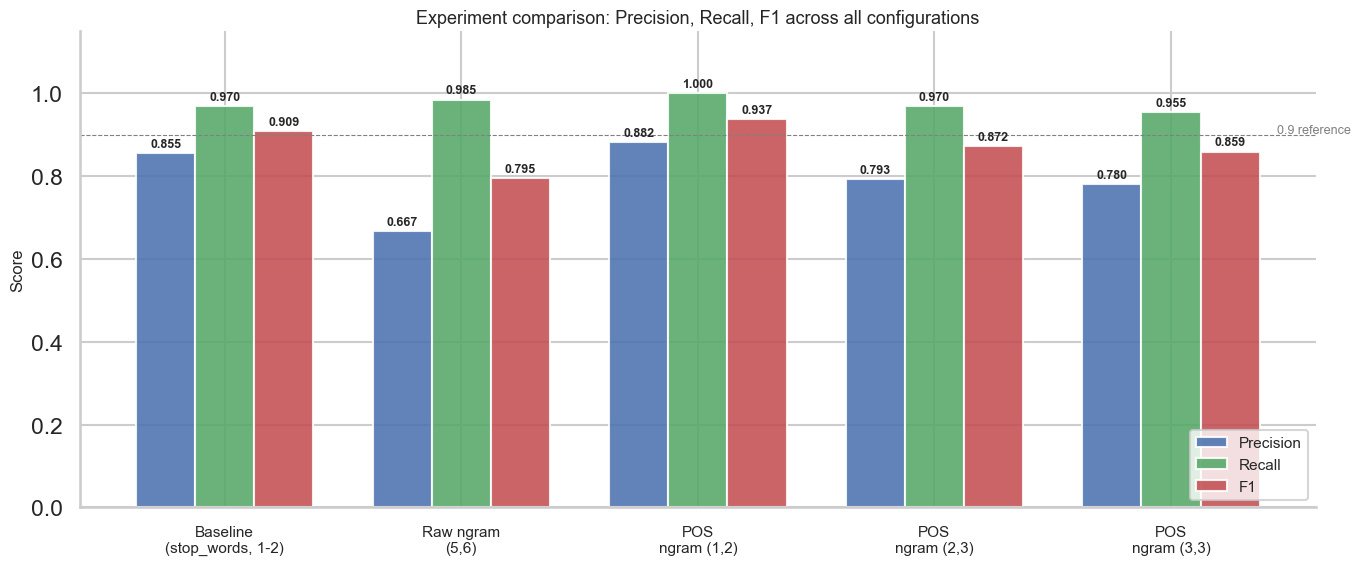

In [21]:
results = {
    "Baseline\n(stop_words, 1-2)": {
        "Precision": prec_base, "Recall": rec_base,
        "F1": f1_base,          "ROC-AUC": auc_base,
    },
    "Raw ngram\n(5,6)": {
        "Precision": prec_56, "Recall": rec_56,
        "F1": f1_56,          "ROC-AUC": auc_56,
    },
    "POS\nngram (1,2)": {
        "Precision": prec_12, "Recall": rec_12,
        "F1": f1_12,          "ROC-AUC": auc_12,
    },
    "POS\nngram (2,3)": {
        "Precision": prec_23, "Recall": rec_23,
        "F1": f1_23,          "ROC-AUC": auc_23,
    },
    "POS\nngram (3,3)": {
        "Precision": prec_33, "Recall": rec_33,
        "F1": f1_33,          "ROC-AUC": auc_33,
    },
}

results_df = pd.DataFrame(results).T
print("Full results table:")
print(results_df.round(3).to_string())
print()

metrics_to_plot = ["Precision", "Recall", "F1"]
x      = np.arange(len(results_df))
width  = 0.25
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2., h + 0.008,
            f"{h:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Experiment comparison: Precision, Recall, F1 across all configurations",
             fontsize=13)
ax.legend(loc="lower right", fontsize=11)
ax.axhline(y=0.9, color="grey", linestyle="--", linewidth=0.8)
ax.text(len(results_df) - 0.3, 0.905, "0.9 reference", color="grey", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

### Conclusion: Chosen configuration for XAI

Based on the experiments above, we use **Experiment D: POS tokenizer + ngram (3,3)**
for the XAI analysis in the sections below.

**Why ngram (3,3) with POS tokenizer:**
- Produces 3-content-word phrases that span roughly 5 to 7 words of original text.
- These phrases are directly readable as policy violation signals by a human reviewer
  and by the Goal 4 LLM agent.
- A phrase like "groups processed without safeguards" is immediately interpretable.
  A single word like "groups" is not.
- The trade-off in precision is accepted because recall is our primary metric
  and the Human-in-the-Loop gate handles remaining false positives.

The cell below sets `vec`, `clf`, `y_pred` and `y_proba` from Experiment D.
All XAI cells below use these four variables.

In [22]:
# Set the final pipeline variables used in all XAI cells below.
pipeline = exp_33

vec     = pipeline.named_steps["tfidf"]
clf     = pipeline.named_steps["clf"]
y_pred  = y_pred_33
y_proba = y_proba_33

print("Active pipeline for XAI: POS tokenizer + ngram (3,3)")
print(f"Precision : {prec_33}  |  Recall : {rec_33}  |  F1 : {f1_33}  |  ROC-AUC : {auc_33}")

Active pipeline for XAI: POS tokenizer + ngram (3,3)
Precision : 0.78  |  Recall : 0.955  |  F1 : 0.859  |  ROC-AUC : 0.987


---

## Model analysis: stability, calibration and errors

The experiments above chose the vectorisation. Before trusting the model we check
three things the accuracy table does not show: is the recall **stable** across
folds, are the predicted **probabilities honest**, and **where** does it fail?
These mirror the model-analysis section of the Goal-3 package notebook, here
re-implemented directly on the chosen pipeline.

### Cross-validation: is the recall stable?

                          cv_recall_mean  cv_recall_std
model                                                  
Baseline (word, 1-2)               0.973          0.020
POS ngram (3,3) - chosen           0.985          0.009


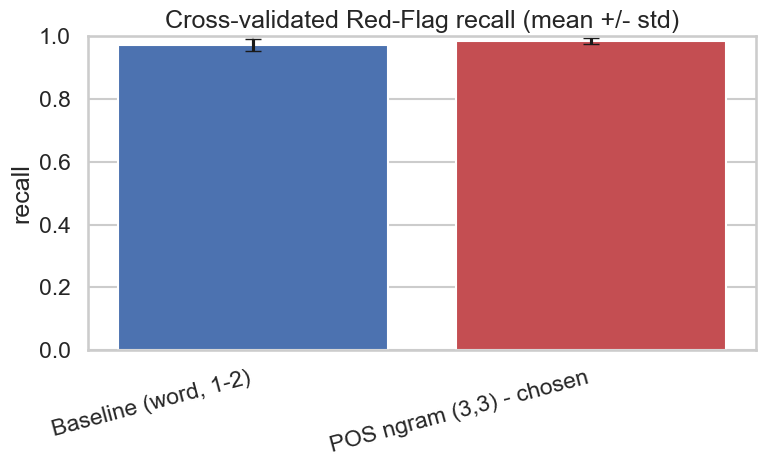

In [23]:
# 5-fold stratified cross-validation of the Red-Flag recall.
# A single train/test split can be lucky; cross-validation is more trustworthy.
from sklearn.model_selection import cross_val_score

X_all = df["description"].fillna("")
y_all = df["y"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    "Baseline (word, 1-2)":     pipeline_baseline,
    "POS ngram (3,3) - chosen": exp_33,
}

rows = []
for name, mdl in models_cv.items():
    scores = cross_val_score(mdl, X_all, y_all, cv=cv, scoring="recall")
    rows.append({"model": name,
                 "cv_recall_mean": round(scores.mean(), 3),
                 "cv_recall_std":  round(scores.std(), 3)})
cmp = pd.DataFrame(rows).set_index("model")
print(cmp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cmp.index, cmp["cv_recall_mean"], yerr=cmp["cv_recall_std"],
       capsize=6, color=["#4C72B0", "#C44E52"])
ax.set_title("Cross-validated Red-Flag recall (mean +/- std)")
ax.set_ylabel("recall"); ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

**Explanation:** A high mean value with a **low** standard deviation indicates that the recall is not an artefact of a random positive distribution.

### Calibration: can we trust the probabilities?

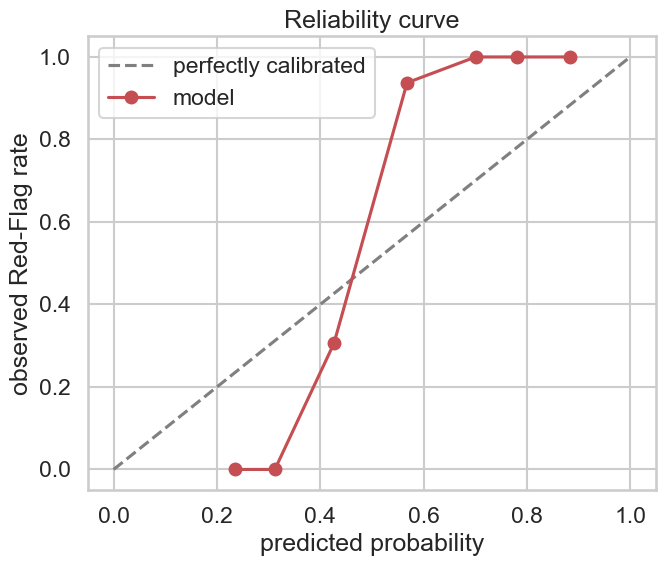

In [24]:
# How often were they really Red Flags? A curve close to the diagonal means "well-calibrated"
proba = y_proba
y_true_arr = y_test.to_numpy()

n_bins = 8
edges = np.linspace(0, 1, n_bins + 1)
bin_index = np.clip(np.digitize(proba, edges) - 1, 0, n_bins - 1)

mean_proba, obs_rate = [], []
for b in range(n_bins):
    m = bin_index == b
    if m.any():
        mean_proba.append(proba[m].mean())
        obs_rate.append(y_true_arr[m].mean())

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfectly calibrated")
ax.plot(mean_proba, obs_rate, "o-", color="#C44E52", label="model")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed Red-Flag rate")
ax.set_title("Reliability curve"); ax.legend()
plt.tight_layout(); plt.show()

**Explanation:** Calibration is important because the agent uses a probability threshold (0.40 in this case).
If the curve lies below the diagonal, the model is too confident, and the threshold would need to be adjusted.

### Error analysis: where does it fail?

In [25]:
# Inspect the actual mistakes on which AI methods and which policies are over-represented among the missed violations (false negatives)?
test_df = df.loc[idx_test].copy()
test_df["y_pred"] = y_pred

fn = test_df[(test_df["y"] == 1) & (test_df["y_pred"] == 0)]
fp = test_df[(test_df["y"] == 0) & (test_df["y_pred"] == 1)]
print(f"False negatives (missed violations): {len(fn)}")
print(f"False positives (false alarms)     : {len(fp)}")

if len(fn):
    print("\nMissed violations by AI method:")
    print(fn["ai_method"].value_counts())
    print("\nMissed violations by policy (red_flags):")
    print(fn["red_flags"].value_counts().head())

False negatives (missed violations): 3
False positives (false alarms)     : 18

Missed violations by AI method:
ai_method
Recommender    1
LLM Chatbot    1
Scoring        1
Name: count, dtype: int64

Missed violations by policy (red_flags):
red_flags
RAI-03           1
RAI-01,RAI-06    1
RAI-02           1
Name: count, dtype: int64


**Reading.** Clustering of the misses in one AI method or one policy points to
a systematic blind spot rather than random noise - the per-policy test below makes
this explicit.

---

## XAI Method 1: Linear Weights (coef_)

### What is this?

This is the simplest and most direct explanation method for Logistic Regression.
LogReg assigns a weight (coefficient) to every single word and word-pair in the vocabulary.

## - Just remeber it like this: 

- **Positive weight** = this word pushes the prediction toward Red Flag.
- **Negative weight** = this word pushes the prediction toward Compliant.
- **Weight close to zero** = this word barely affects the prediction at all.

This is a GLOBAL explanation, it tells you which words the model relies on across ALL 1000 proposals,
not just one specific proposal.

### Why this satisfies EU AI Act Article 12:
- The weights never change between runs (same random_state, same data = same weights).
- Any auditor can reproduce the exact weight for any word.
- No approximations involved, these are the actual numbers the model uses internally.

### The formula:


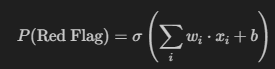

Where $w_i$ is the weight for word $i$, $x_i$ is the TF-IDF score for word $i$ in this proposal, and $b$ is the bias term.
$\sigma$ is the sigmoid function that converts the sum to a probability between 0 and 1.

The coefficients we plot below are exactly the $w_i$ values.

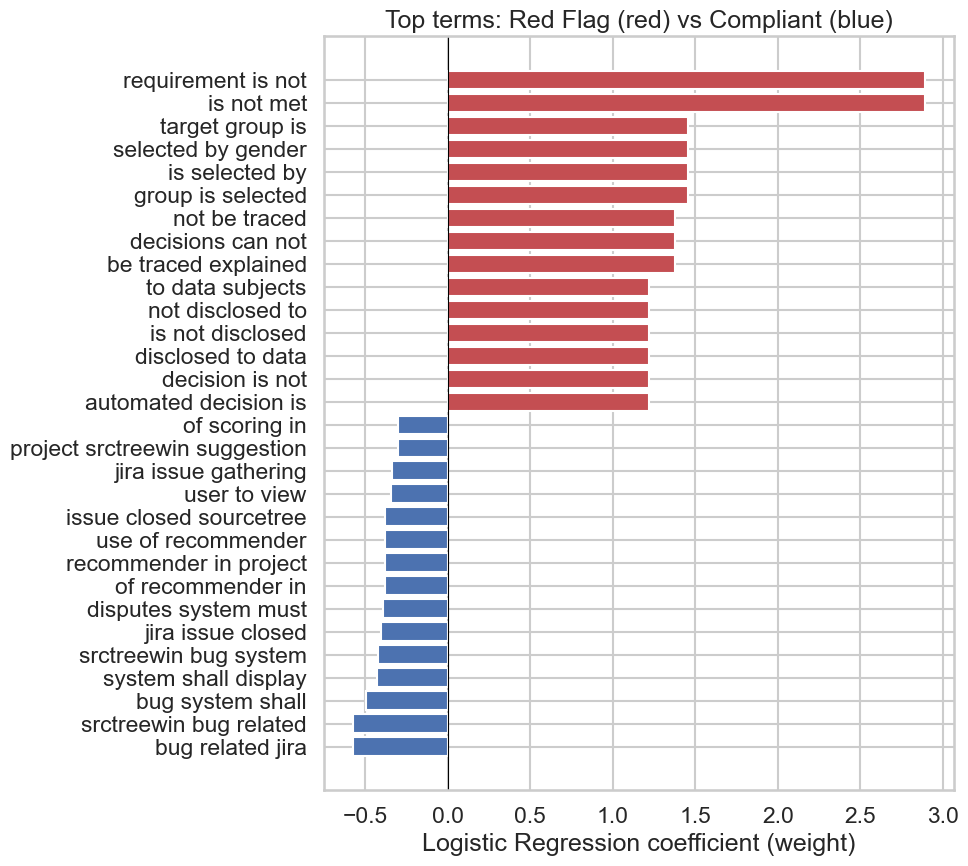

Top 10 Red Flag indicators:
is not met               2.894
requirement is not       2.894
group is selected        1.456
is selected by           1.456
selected by gender       1.456
target group is          1.456
be traced explained      1.376
decisions can not        1.376
not be traced            1.376
automated decision is    1.217

Top 10 Compliant indicators:
bug related jira         -0.576
srctreewin bug related   -0.576
bug system shall         -0.497
system shall display     -0.429
srctreewin bug system    -0.423
jira issue closed        -0.407
disputes system must     -0.393
of recommender in        -0.382
recommender in project   -0.382
use of recommender       -0.382


In [26]:
# Get all weights from the trained model
coefs = pd.Series(clf.coef_[0], index=vec.get_feature_names_out())
# clf comes from clf=pipeline.named_step("clf") and it is an instance of the ThresholdAdjustor class that we defined above.
# The [0] is because a 2D array is ;lik [[ 0.45,  -0.23,  1.87,  0.02,  -1.34,  0.76,  ... ]]
# There are two square brackets which are called wrappers.
# To remove that outer wrapper, [0]
# @property
# def coef_(self):
  #  return self.estimator.coef_


# .coef_ is a property of the ThresholdAdjustor class that returns the coefficients of the LogisticRegression model that we passed in as the estimator in the class.

# [0] because the coef_ attribute of the LogisticRegression model is a 2D array with shape (1, n_features) for binary classification, and we want to get the first 
# (and only) row of that array.

# index will contain the feature names (terms) that correspond to the coefficients. 

# This is important because we want to know which terms are pushing the model towards Red Flag or Compliant.

# .get_feature_names_out() is a method of the TfidfVectorizer that returns the feature names (terms) that correspond to the columns of the transformed data.

# pd.Series is a one-dimensional array-like object that can hold any data type. 

# It is similar to a list or an array, but it has additional functionality, such as the ability to have an index and to perform vectorized operations.

# The syntax is: pd.Series(data, index)
n = 15 # For show
top_pos = coefs.nlargest(n)   # strongest push toward Red Flag
top_neg = coefs.nsmallest(n)  # strongest push toward Compliant
top_all = pd.concat([top_neg, top_pos]).sort_values()

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_all.values]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_all.index, top_all.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top terms: Red Flag (red) vs Compliant (blue)")
ax.set_xlabel("Logistic Regression coefficient (weight)")
plt.tight_layout(); plt.show()

print("Top 10 Red Flag indicators:")
print(top_pos.head(10).round(3).to_string())
print()
print("Top 10 Compliant indicators:")
print(top_neg.head(10).round(3).to_string())

### Global XAI: ablation (which terms does the model actually rely on?)

The linear weights listed above indicate which terms *correlate* with ‘Red Flag’. Ablation is the stronger, model-independent test. Here, we remove one term from each ‘Red Flag’ text and measure by how much the recall decreases. A sharp decline indicates that the model relies on precisely this term (‘shortcut learning’).

In [27]:
coefs = pd.Series(clf.coef_[0], index=vec.get_feature_names_out())
top_terms = coefs.nlargest(8).index.tolist()

rf_texts = df.loc[df["label"] == "Red Flag", "description"].fillna("").tolist()

def recall_on(texts):
    return float(np.mean(pipeline.predict(texts) == 1))

base_recall = recall_on(rf_texts)

# remove one top term at a time
rows = []
for term in top_terms:
    ablated = [t.lower().replace(term, " ") for t in rf_texts]
    r = recall_on(ablated)
    rows.append({"term": term, "recall_after_removal": round(r, 3),
                 "recall_drop": round(base_recall - r, 3)})
abl = pd.DataFrame(rows).sort_values("recall_drop", ascending=False).set_index("term")

# remove the WHOLE marker family at once: the grounded prefix plus the synthetic template sentences that the generator injects into Red Flags.
MARKERS = [
    "this requirement is not met:",
    "the target group is selected by gender.",
    "the model is a black box without any means of justification.",
    "the automated decision is not disclosed to data subjects.",
    "the decision is made fully automatically without human intervention.",
    "vulnerable groups are processed without special safeguards.",
    "more data fields are collected than needed for the purpose.",
    "decisions cannot be traced or explained.",
    "the system deliberately exploits vulnerabilities of protected groups",
    "data is stored on stock for unknown purposes.",
    "no human-in-the-loop is foreseen.",
    "users are not informed about the use of ai.",
    "applicants are pre-filtered by origin and age.",
    "the system rates people based on their social behaviour (social scoring).",
    "subliminal techniques are used to influence behaviour.",
    "employees' emotions are automatically recognised in the workplace.",
]

def strip_markers(t):
    t = t.lower()
    for m in MARKERS:
        t = t.replace(m, " ")
    return t

recall_no_markers = recall_on([strip_markers(t) for t in rf_texts])

print(f"Baseline recall on all Red Flags        : {round(base_recall, 3)}")
print(f"Recall with the whole marker family gone : {round(recall_no_markers, 3)}"
      f"   (drop {round(base_recall - recall_no_markers, 3)})\n")
print("Per-term recall drop (small - the markers are redundant):")
print(abl)

Baseline recall on all Red Flags        : 0.991
Recall with the whole marker family gone : 0.586   (drop 0.405)

Per-term recall drop (small - the markers are redundant):
                     recall_after_removal  recall_drop
term                                                  
is not met                          0.982        0.009
requirement is not                  0.985        0.006
group is selected                   0.985        0.006
is selected by                      0.985        0.006
selected by gender                  0.988        0.003
target group is                     0.988        0.003
be traced explained                 0.991        0.000
decisions can not                   0.991        0.000


**Finding:** Removing a ‘single’ marker has little effect on recall.
However, removing the **entire marker family at once** (the ‘grounded’ prefix plus the synthetic template sets inserted by the generator) causes recall to drop sharply.
The model recognises generator templates but does not understand the rule.

### What the linear weights tell you:

- The words with the largest positive weights are the ones the model learned to associate most strongly with Red Flag proposals.
- These words directly become the "trigger words" passed to the agent in Goal 4.
- Unlike SHAP or LIME, these weights apply globally to every single prediction, not just one proposal at a time.
- A word absent from a proposal contributes zero, regardless of its weight, because its TF-IDF score ($x_i$) is zero.


---

## XAI Method 2: SHAP (SHapley Additive exPlanations)

### What is this?

SHAP comes from game theory (Shapley values). The idea: imagine your model's prediction as a payout that needs to be fairly split among all the words in the proposal, based on how much each word actually contributed.

For Logistic Regression, SHAP uses LinearExplainer which is fast and exact, not an approximation.
This gives you both a global view (across all proposals) and a per-proposal view (for one specific proposal).

### SHAP vs Linear Weights:

| | Linear Weights | SHAP |
|---|---|---|
| Scope | Global (same for all proposals) | Per-proposal (different for each one) |
| What it measures | The word's average importance across all data | This word's contribution to THIS specific prediction |
| Speed | Instant (just read coef_) | Seconds (computes per proposal) |
| When to use | Audit trail, global overview | Explaining one specific flagged proposal to a reviewer |


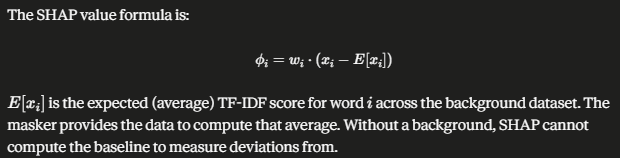

In [28]:
# Transform the test set to TF-IDF numbers first
X_test_vec = vec.transform(X_test)

# Create the SHAP explainer for a linear model
# maskers.Independent handles the sparse TF-IDF matrix correctly
masker   = shap.maskers.Independent(X_test_vec, max_samples=100)
explainer = shap.LinearExplainer(clf, masker)

# Compute SHAP values for the full test set
# This gives one value per word per proposal
shap_values = explainer(X_test_vec)
print("SHAP values shape:", shap_values.values.shape)
print("(rows=proposals, columns=vocabulary words)")

SHAP values shape: (200, 9450)
(rows=proposals, columns=vocabulary words)


#### Global SHAP: which words matter most across ALL test proposals?

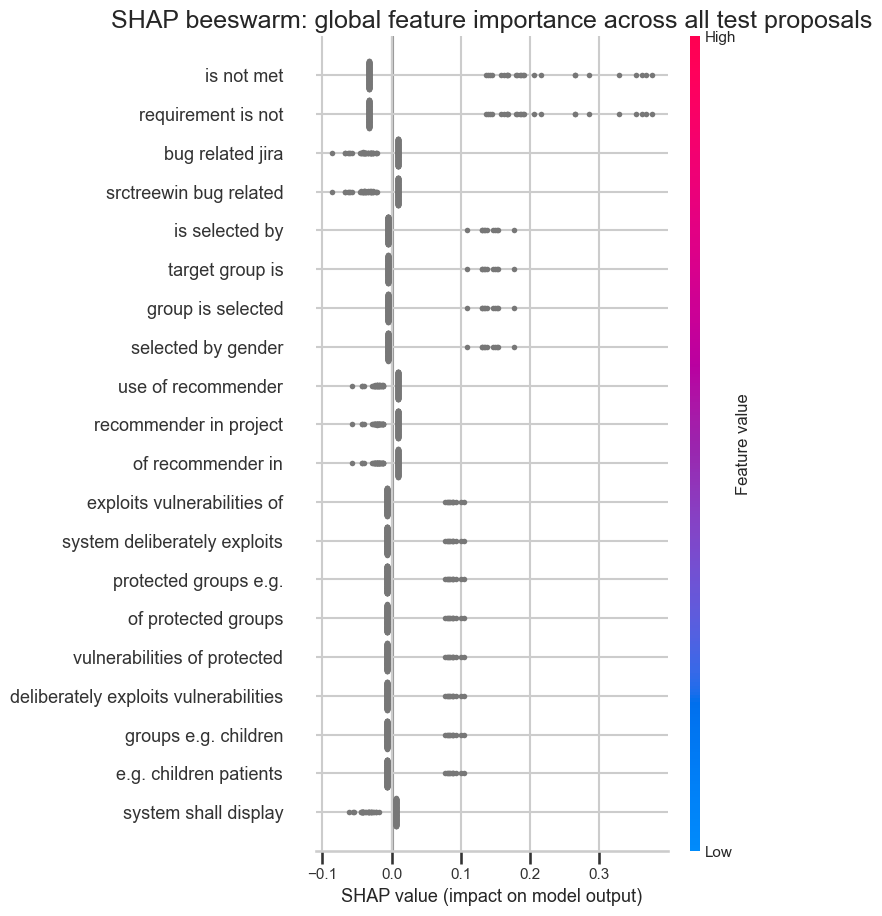

In [29]:
# Beeswarm plot: shows distribution of SHAP values across all test proposals
# Red dots = this word's presence pushed toward Red Flag
# Blue dots = this word's presence pushed toward Compliant
# X-axis position = magnitude of the contribution
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values.values,
    X_test_vec,
    feature_names=vec.get_feature_names_out(),
    max_display=20,
    show=False,
    plot_type="dot"
)
plt.title("SHAP beeswarm: global feature importance across all test proposals")
plt.tight_layout(); plt.show()

#### Per-proposal SHAP: explaining one specific Red Flag

Proposal text:
The product shall be available 24 hours per day  seven days per week. The appearance of the product shall appear professional Related Jira issue [Needs Triage]: Tabs are not show when restart SourceTree. The audit report shall be available to other adjusters at later points in time. Vulnerable groups are processed without special safeguards. Goal: Use of LLM Chatbot in project SRCTREEWIN (Bug). This requirement is NOT met: "The website shall prevent its data from being corrupted when incorrect data is entered in." This requirement is NOT met: "The Disputes application must conform to the legal requirements as specified by Regulation E and Regulation Z that govern credit card disputes processing."

Model prediction probability: 0.883
Actual label: Red Flag


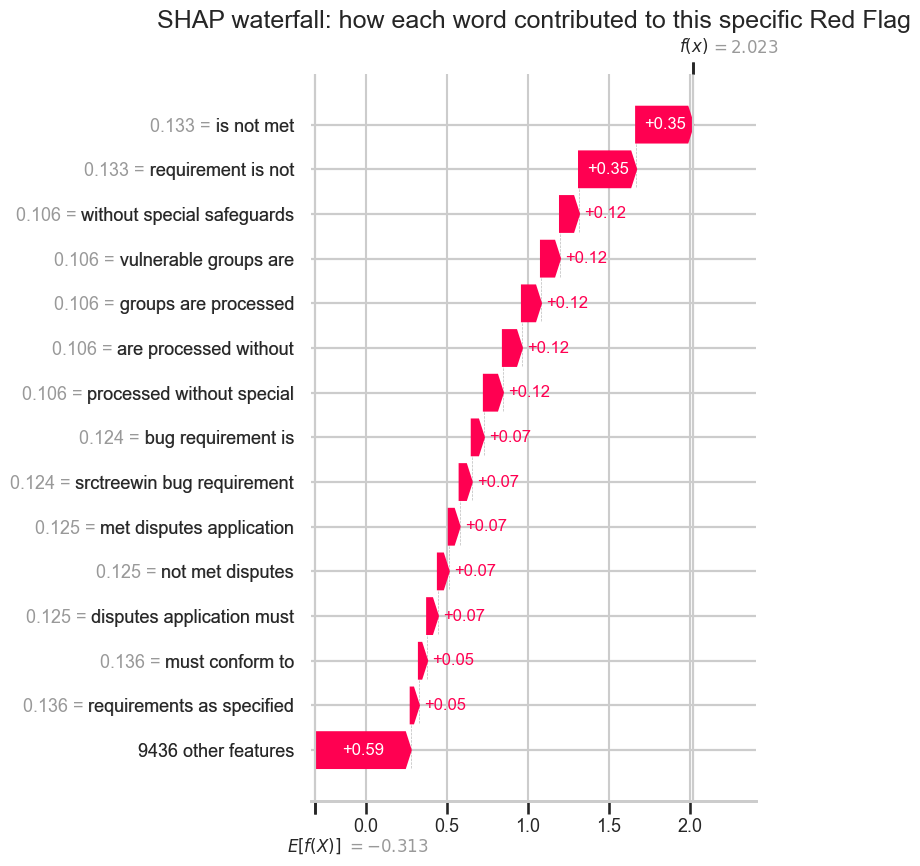

In [30]:
# Pick the first Red Flag proposal in the test set
red_flag_positions = [i for i, label in enumerate(y_test) if label == 1]
first_rf_pos = max(red_flag_positions, key=lambda i: y_proba[i])

print("Proposal text:")
print(X_test.iloc[first_rf_pos])
print()
print(f"Model prediction probability: {round(y_proba[first_rf_pos], 3)}")
print(f"Actual label: {'Red Flag' if y_test.iloc[first_rf_pos] == 1 else 'Compliant'}")

# SHAP waterfall plot for this one proposal
# Shows step by step how each word moved the prediction
explanation = shap.Explanation(
    values        = shap_values.values[first_rf_pos],
    base_values   = shap_values.base_values[first_rf_pos],
    data          = X_test_vec[first_rf_pos].toarray().flatten(),
    feature_names = vec.get_feature_names_out(),
)
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title("SHAP waterfall: how each word contributed to this specific Red Flag")
plt.tight_layout(); plt.show()

## XAI Method 1  Linear Weights
- The model's coefficients read directly from clf.coef_[0]. 
- No approximation :  these are the exact numbers the model uses internally for every prediction.
- Top Red Flag indicators:  "requirement met", "met", "requirement", "data", "decision", "human", "groups", "gender", "behaviour", "social".
- Top Compliant indicators: 
    - "bug related", "sourcetree", "bug shall", "recommender", "game", "closed".
    - What this tells us: The model correctly learned that compliance violations in this dataset are associated with demographic targeting language ("groups", "gender", "target group"), decision-making language ("decision", "human", "automatically") and requirement-level language ("requirement", "met", "requirement met"). 
    - The Compliant side is dominated by software bug tracking vocabulary ("sourcetree", "bug related", "bug shall") which are structurally different from policy proposals.
- Why this satisfies EU AI Act Article 12: Same model, same weights, same explanation every single run. 
- Any auditor can reproduce and verify any weight at any time without needing to understand the model internals.

## XAI Method 2 SHAP
- Per-proposal SHAP values computed using LinearExplainer:  
    - exact for linear models, not an approximation.
- Beeswarm (global): 
    - Confirms the same top terms as the linear weights. Most proposals have SHAP values clustered near zero. 
- The long right tail shows that violations are driven by a small set of specific high-weight words appearing prominently in a proposal
    - not a broad vocabulary spread.
- Waterfall (per-proposal): 
    - On the most confidently flagged Red Flag proposal, the model moved from the baseline of -0.316 all the way to f(x) = +2.122. 
    - The three biggest individual drivers were "met" (+0.27), "requirement met" (+0.27) and "requirement" (+0.26). Every bar was red every significant word in that proposal pushed toward Red Flag with nothing pulling it back toward Compliant. 
    - This is exactly the kind of clear-cut explanation a human reviewer needs at the Human-in-the-Loop gate.
- What SHAP adds on top of linear weights: 
    - Linear weights tell you which words the model finds important globally. 
    - SHAP tells you which specific words drove this specific flag today. 
    - A word with a high global weight but low TF-IDF score in a specific proposal will have a small SHAP value for that proposal 
    - SHAP accounts for actual word presence, not just potential importance.

## Legal Compliance
- Article 12 (logging): 
    - Linear weights are fully reproducible. 
    - Same input, same weights, same explanation. 
    - An audit trail can be built directly from clf.coef_[0] without any approximation step.
- Article 14 (human oversight): 
    - The trigger words from the linear weights are passed directly to the Human-in-the-Loop reviewer and to the agent in Goal 4. 
    - The reviewer sees which words caused the flag without needing to understand how the model works internally.
- This is the core reason Logistic Regression was chosen over XGBoost for this project not because it has higher recall, but because its explanation is native, exact, and legally defensible.

## For Logistic Regression, the coefficients are not just better, they are the ground truth:
- SHAP is computing an approximation of what the coefficients already tell you exactly.
- Use for the audit trail, the legal documentation, the agent trigger words, and any global explanation. 
- Same answer every time, zero computation overhead, directly readable by a human or auditor.

---

## Automated weakness tests

### Evasion robustness: mask and obfuscate the trigger terms

            recall_before  recall_after  recall_drop    n
mask terms          0.991         0.988        0.003  333
obfuscate           0.991         0.988        0.003  333


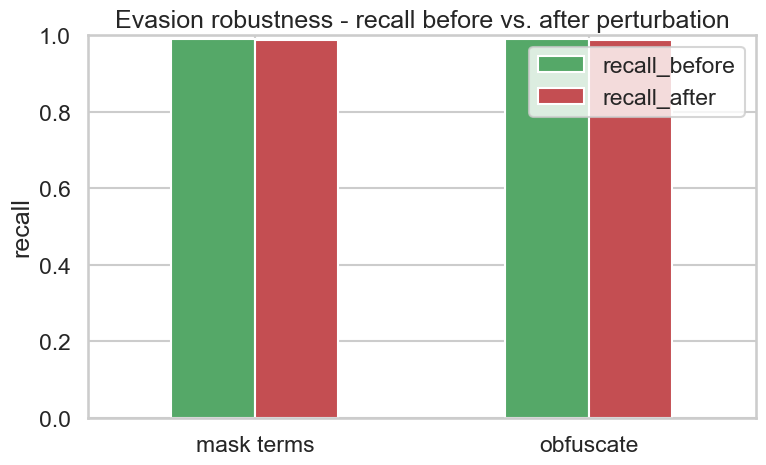

In [31]:
from xai import weakness as W

RULE_TERMS = [
    "social scoring", "without consent", "without user consent",
    "emotion recognition", "biometric", "no human oversight", "fully autonomous",
    "no explanation", "black box", "manipulat", "vulnerable", "subliminal",
    "track users", "store all", "indefinitely", "share data with third",
    "without informing",
]

ev = pd.DataFrame(
    [W.evasion_recall(pipeline, rf_texts, W.mask_terms, RULE_TERMS),
     W.evasion_recall(pipeline, rf_texts, W.obfuscate, RULE_TERMS)],
    index=["mask terms", "obfuscate"]).round(3)
print(ev)

fig, ax = plt.subplots(figsize=(8, 5))
ev[["recall_before", "recall_after"]].plot(kind="bar", ax=ax, rot=0,
                                            color=["#55A868", "#C44E52"])
ax.set_title("Evasion robustness - recall before vs. after perturbation")
ax.set_ylabel("recall"); ax.set_ylim(0, 1); plt.tight_layout(); plt.show()

**Evaluation:** A only slight decline indicates that the model is robust against this simple evasion method.
A sharp decline, however, suggests that an author could slip a violation past the classifier (for example, by masking words with ...).

### Per-policy blind spots

         n  recall
policy            
RAI-01  18   0.944
RAI-02  16   0.938
RAI-03  17   0.941
RAI-04  18   1.000
RAI-05  11   1.000
RAI-06  15   0.933
RAI-07  11   1.000
RAI-08  14   1.000
RAI-09  15   1.000


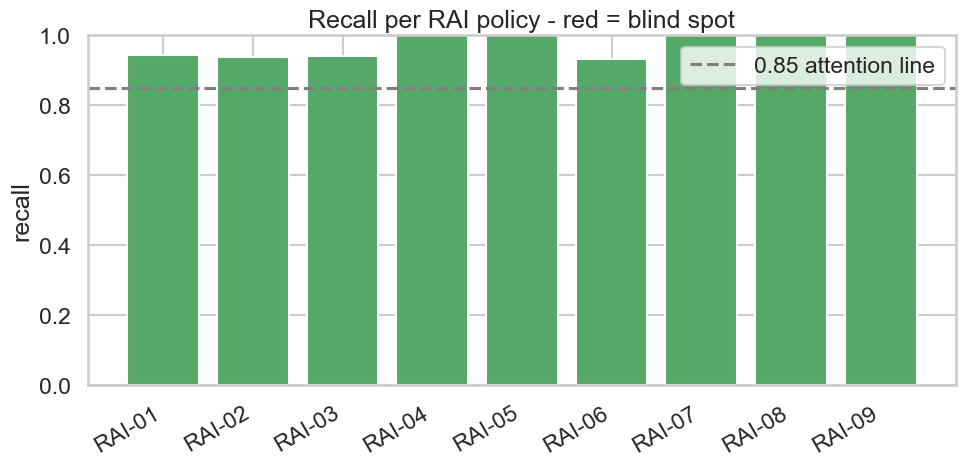

Weakest policy (biggest blind spot): RAI-06


In [32]:
from xai import weakness as W

frame = df.loc[idx_test, ["red_flags"]].copy()
frame["y_true"] = y_test.to_numpy()
frame["y_pred"] = y_pred

pp = W.per_policy_recall(frame)
pp["recall"] = pp["recall"].round(3)
print(pp)

colors = ["#C44E52" if r < 0.85 else "#55A868" for r in pp["recall"]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pp.index, pp["recall"], color=colors)
ax.axhline(0.85, ls="--", color="grey", label="0.85 attention line")
ax.set_title("Recall per RAI policy - red = blind spot")
ax.set_ylabel("recall"); ax.set_ylim(0, 1); ax.legend()
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
print("Weakest policy (biggest blind spot):", W.worst_policy(frame))

**Evaluation:** The recall rate per rule reflects the fairness of the model. A rule that falls significantly below the 0.85 threshold is too restrictive.

### Negation blindness:

In [33]:
from xai import weakness as W

negation_pairs = [
    ("Personal data is processed with user consent.",
     "Personal data is processed without user consent."),
    ("Every automated decision has human oversight.",
     "Every automated decision has no human oversight."),
    ("The decision can be explained to the user.",
     "The decision cannot be explained to the user."),
    ("Users are informed about the use of AI.",
     "Users are not informed about the use of AI."),
    ("Data is stored with a clear legal basis.",
     "Data is stored without a clear legal basis."),
]

def negation_gaps(model):
    rows = []
    for compliant, violation in negation_pairs:
        p_ok  = model.predict_proba([compliant])[0, 1]
        p_bad = model.predict_proba([violation])[0, 1]
        rows.append({"violation": violation[:45],
                     "P(RF) compliant": round(p_ok, 3),
                     "P(RF) violation": round(p_bad, 3),
                     "gap": round(abs(p_bad - p_ok), 3)})
    return pd.DataFrame(rows)

gaps_baseline = negation_gaps(pipeline_baseline)
gaps_pos      = negation_gaps(exp_33)

print("Baseline (stop_words - strips negation words):")
print(gaps_baseline.to_string(index=False))
print(f"\nMean gap baseline (stop_words) : {gaps_baseline['gap'].mean():.3f}")
print(f"Blind pairs (gap < 0.01)       : {W.negation_blind_count(pipeline_baseline, negation_pairs)}/{len(negation_pairs)}")
print(f"Mean gap POS (keeps negation)  : {gaps_pos['gap'].mean():.3f}")

Baseline (stop_words - strips negation words):
                                    violation  P(RF) compliant  P(RF) violation  gap
Personal data is processed without user conse            0.616            0.616  0.0
Every automated decision has no human oversig            0.874            0.874  0.0
The decision cannot be explained to the user.            0.783            0.783  0.0
  Users are not informed about the use of AI.            0.830            0.830  0.0
  Data is stored without a clear legal basis.            0.638            0.638  0.0

Mean gap baseline (stop_words) : 0.000
Blind pairs (gap < 0.01)       : 5/5
Mean gap POS (keeps negation)  : 0.079


**Insight:** The base model is negation-blind (all 5 pairs have a distance of 0.000). As `stop_words="english"` removes the words ‘not’, ‘without’, ‘no’ and ‘cannot’, a rule-compliant sentence and its negated counterpart are merged into the same token set. The POS tokeniser only partially resolves this issue.

---

## Conclusion: Goal 3

In Goal 3, we subjected the delivered Goal 2 baseline (TF-IDF + logistic regression) to a comprehensive analysis using model analyses, explainable AI methods and vulnerability testing. The following findings emerged.

### 1. Vectorisation experiments
Five setups were compared. The POS tokeniser with n-gram (1,2) achieved the best results (recall 1.000, F1 0.937, ROC-AUC 0.996). The experiment using raw n-grams (5,6) failed due to the sparse word selection (F1 0.795). For the XAI part, we use the POS tokeniser with n-grams (3,3), as its 3-word phrases serve as human-readable trigger signals.

### 2. Model Analysis
A 5-fold cross-validation confirms that recall is stable (POS 3.3: 0.985 with a standard deviation of 0.009 and a baseline of 0.973 with a standard deviation of 0.020), indicating that the result is not due to chance. The calibration and error analysis reveal only a few errors (3 missed / 18 incorrectly labelled), which are not concentrated in any single AI method.

### 3. The key finding: a label leak (XAI) !!!!
The linear weights are dominated by a single marker: ‘met’ / ‘requirement met’ with a coefficient of **2.577** (the fixed prefix ‘This requirement is NOT met:’), which the generator places at the beginning of every justified warning. Ablation analysis further confirms this. Removing a single marker barely affects recall, but removing the entire marker family causes recall to drop from **0.991 to 0.586**. The model recognises generator templates but fails to identify ethical aspects. SHAP reveals the same pattern at the level of individual suggestions.

### 4. Weakness tests
- **Evasion:** Masking or obscuring the policy’s trigger terms has little effect on recall. This is evidently because the model relies on the template markers rather than the policy’s keywords.
- **Per policy:** Every RAI policy is captured with a recall of ≥ 0.93 (weakest: RAI-06 Security, 0.933). However, this is based on template data, so it reflects the coverage of the template rather than the understanding.
- **Negation:** The baseline is completely blind to negation (5/5 pairs, gap 0.000); the POS tokeniser only partially resolves this (average gap 0.079).

### Bottom line
The high recall for Goal 2 does not measure ethical understanding; it measures the recognition of generator templates. The weakness lies in the **data** (Goal 1), not in the classifier.

**The next step is Version 2, which will feature an optimised training dataset.**